Problem: If Peter wants to escape from the wolf, he needs to be able to move faster. We will see how Peter can learn to skate, in particular, to keep balance, using Q-Learning


We will use a simplified version of balancing known as a CartPole problem. In the cartpole world, we have a horizontal slider that can move left or right, and the goal is to balance a vertical pole on top of the slider.

OpenAI Gym


In the previous lesson, the rules of the game and the state were given by the Board class which we defined ourselves. Here we will use a special simulation environment, which will simulate the physics behind the balancing pole. One of the most popular simulation environments for training reinforcement learning algorithms is called a Gym, which is maintained by OpenAI. By using this gym we can create difference environments from a cartpole simulation to Atari games.

In [35]:
import gymnasium
import matplotlib.pyplot as plt
import numpy as np 
import random

initialize a cartpole environment


To work with a cartpole balancing problem, we need to initialize corresponding environment. Each environment is associated with an:


Observation space that defines the structure of information that we receive from the environment. For cartpole problem, we receive position of the pole, velocity and some other values.


Action space that defines possible actions. In our case the action space is discrete, and consists of two actions - left and right. (code block 2)



In [5]:
env = gym.make("CartPole-v1")
print(env.action_space)
print(env.observation_space)
print(env.action_space.sample())

Discrete(2)
Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
1


To see how the environment works, we can run a short simulation for 100 steps. At each step, we provide one of the actions to be taken - in this simulation we just randomly select an action from action_space.

In [11]:
env.reset()

for i in range(100):
    env.render()
    env.step(env.action_space.sample())
env.close()

During simulation, we need to get observations in order to decide how to act. In fact, the step function returns current observations, a reward function, and the done flag that indicates whether it makes sense to continue the simulation or not:

In [14]:
env.reset()

done = False
terminated = False
truncated = False
# Change this:
# while not done:

# To this:
while not (terminated or truncated):
    obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
    print(f"{obs} -> {rew}")

env.close()

[ 0.03847079  0.24130489 -0.04290993 -0.32412827] -> 1.0
[ 0.04329689  0.43701074 -0.04939249 -0.6300285 ] -> 1.0
[ 0.0520371   0.24261154 -0.06199306 -0.35330078] -> 1.0
[ 0.05688934  0.04842338 -0.06905908 -0.08079237] -> 1.0
[ 0.0578578  -0.14564413 -0.07067493  0.18932779] -> 1.0
[ 0.05494492  0.05041402 -0.06688837 -0.12478641] -> 1.0
[ 0.0559532   0.2464273  -0.0693841  -0.43779936] -> 1.0
[ 0.06088175  0.05235252 -0.07814009 -0.1677702 ] -> 1.0
[ 0.0619288  -0.14156903 -0.08149549  0.0992747 ] -> 1.0
[ 0.05909742  0.05462061 -0.07951    -0.2179662 ] -> 1.0
[ 0.06018983 -0.13928004 -0.08386932  0.04861457] -> 1.0
[ 0.05740423 -0.33310547 -0.08289703  0.3137021 ] -> 1.0
[ 0.05074212 -0.5269547  -0.07662299  0.5791336 ] -> 1.0
[ 0.04020302 -0.72092396 -0.06504031  0.8467287 ] -> 1.0
[ 0.02578454 -0.52497786 -0.04810574  0.5343226 ] -> 1.0
[ 0.01528499 -0.71939147 -0.03741929  0.81146806] -> 1.0
[ 8.9715823e-04 -9.1398138e-01 -2.1189926e-02  1.0921499e+00] -> 1.0
[-1.7382469e-02 -1.

The observation vector that is returned at each step of the simulation contains the following values:

Position of cart

Velocity of cart

Angle of pole

Rotation rate of pole


Get min and max value of those numbers

In [15]:
print(env.observation_space.low)
print(env.observation_space.high)

[-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38]
[4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38]


State discretization

Here is the function that will take the observation from our model and produce a tuple of 4 integer values

In [29]:
import numpy as np

def discretize(x):
    # Handle both tuple and array input
    if isinstance(x, tuple):
        x = x[0]  # Extract observation from (obs, info) tuple
    
    x = np.array(x).flatten()
    return tuple((x / np.array([0.25, 0.25, 0.01, 0.1])).astype(int))

Let's also explore another discretization method using bins:

In [20]:
def create_bins(i, num):
    return np.arange(num+1)*(i[1] - i[0])/num+i[0]

print("Sample bins for interval (-5,5) with 10 bins\n", create_bins((-5,5),10))

ints = [(-5,5),(-2,2),(-0.5,0.5),(-2,2)] #intervals of values for each parameter
nbins = [20,20,10,10] #number of bins for each parameter
bins = [create_bins(ints[i],nbins[i]) for i in range(4)]

def discretize_bins(x):
    return tuple(np.digitize(x[i],bins[i])for i in range(4))

Sample bins for interval (-5,5) with 10 bins
 [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]


Now we run a short simulation and observe those discrete environment values. Feel free to try both discretize and discretize_bins and see if there is a difference.


✅ discretize_bins returns the bin number, which is 0-based. Thus for values of input variable around 0 it returns the number from the middle of the interval (10). In discretize, we did not care about the range of output values, allowing them to be negative, thus the state values are not shifted, and 0 corresponds to 0. (code block 8)

In [21]:
env.reset()

done = False
terminated = False
truncated = False
# Change this:
# while not done:

# To this:
while not (terminated or truncated):
    obs, rew, terminated, truncated, info = env.step(env.action_space.sample())
    print(discretize_bins(obs))
    print(discretize(obs))

env.close()

(np.int64(10), np.int64(12), np.int64(6), np.int64(5))
(np.int64(0), np.int64(0), np.int64(4), np.int64(-2))
(np.int64(10), np.int64(13), np.int64(6), np.int64(4))
(np.int64(0), np.int64(1), np.int64(3), np.int64(-5))
(np.int64(10), np.int64(12), np.int64(6), np.int64(5))
(np.int64(0), np.int64(0), np.int64(2), np.int64(-2))
(np.int64(10), np.int64(11), np.int64(6), np.int64(6))
(np.int64(0), np.int64(0), np.int64(2), np.int64(0))
(np.int64(10), np.int64(10), np.int64(6), np.int64(6))
(np.int64(0), np.int64(0), np.int64(2), np.int64(3))
(np.int64(10), np.int64(9), np.int64(6), np.int64(7))
(np.int64(0), np.int64(-1), np.int64(3), np.int64(6))
(np.int64(10), np.int64(10), np.int64(6), np.int64(6))
(np.int64(0), np.int64(0), np.int64(4), np.int64(3))
(np.int64(10), np.int64(11), np.int64(6), np.int64(6))
(np.int64(0), np.int64(0), np.int64(5), np.int64(1))
(np.int64(10), np.int64(10), np.int64(6), np.int64(7))
(np.int64(0), np.int64(0), np.int64(5), np.int64(4))
(np.int64(10), np.int64(9

The Q-Table structure

In our previous lesson, the state was a simple pair of numbers from 0 to 8, and thus it was convenient to represent Q-Table by a numpy tensor with a shape of 8x8x2. If we use bins discretization, the size of our state vector is also known, so we can use the same approach and represent state by an array of shape 20x20x10x10x2 (here 2 is the dimension of action space, and first dimensions correspond to the number of bins we have selected to use for each of the parameters in observation space).


However, sometimes precise dimensions of the observation space are not known. In case of the discretize function, we may never be sure that our state stays within certain limits, because some of the original values are not bound. Thus, we will use a slightly different approach and represent Q-Table by a dictionary.


Use the pair (state,action) as the dictionary key, and the value would correspond to Q-Table entry value. (code block 9)

In [22]:
Q = {}
actions = (0,1)

def qvalues(state):
    return[Q.get((state,a),0) for a in actions]

Now we are ready to teach Peter to balance

In [31]:
#hyperparameters
alpha = 0.3
gamma = 0.9
epsilon = 0.90

Collect all cumulative rewards at each simulation at rewards vector for further plotting

In [33]:
def probs(v, eps=1e-4):
    v = np.array(v)  # Convert to numpy array first
    V = v - v.min() + eps
    V = V / V.sum()
    return V

Qmax = 0
cum_rewards = []
rewards = []

for epoch in range(100000):
    # Fix: Handle tuple return from reset()
    result = env.reset()
    if isinstance(result, tuple):
        obs, info = result
    else:
        obs = result
    
    terminated = False
    truncated = False
    cum_reward = 0

    # == do the simulation ==
    while not (terminated or truncated):
        s = discretize(obs)
        if random.random() > epsilon:  # Note: Should be '>' not '<' for exploitation
            # exploitation - choose the action according to Q-Table probabilities
            v = probs(qvalues(s))  # Fixed: removed np.random() - doesn't make sense here
            a = random.choices(actions, weights=v)[0]
        else:
            # exploration - randomly choose the action
            a = np.random.randint(env.action_space.n)

        obs, rew, terminated, truncated, info = env.step(a)
        cum_reward += rew
        ns = discretize(obs)
        Q[(s,a)] = (1 - alpha) * Q.get((s,a), 0) + alpha * (rew + gamma * max(qvalues(ns)))
    
    cum_rewards.append(cum_reward)
    rewards.append(cum_reward)
    
    # == periodically print results and calculate average reward == 
    if epoch % 5000 == 0:
        print(f"{epoch}: {np.average(cum_rewards)}, alpha={alpha}, epsilon={epsilon}")  # Fixed typo: cum_rewrds -> cum_rewards
        if np.average(cum_rewards) > Qmax:
            Qmax = np.average(cum_rewards) 
            Qbest = Q
        cum_rewards = []  # Fixed typo: cum_rewrds -> cum_rewards        

0: 30.0, alpha=0.3, epsilon=0.9
5000: 25.1368, alpha=0.3, epsilon=0.9
10000: 26.274, alpha=0.3, epsilon=0.9
15000: 26.4318, alpha=0.3, epsilon=0.9
20000: 26.5414, alpha=0.3, epsilon=0.9
25000: 26.555, alpha=0.3, epsilon=0.9
30000: 26.589, alpha=0.3, epsilon=0.9
35000: 26.5812, alpha=0.3, epsilon=0.9
40000: 26.2024, alpha=0.3, epsilon=0.9
45000: 26.0308, alpha=0.3, epsilon=0.9
50000: 26.0974, alpha=0.3, epsilon=0.9
55000: 26.151, alpha=0.3, epsilon=0.9
60000: 25.8154, alpha=0.3, epsilon=0.9
65000: 26.2634, alpha=0.3, epsilon=0.9
70000: 25.8962, alpha=0.3, epsilon=0.9
75000: 26.1312, alpha=0.3, epsilon=0.9
80000: 25.4976, alpha=0.3, epsilon=0.9
85000: 25.9172, alpha=0.3, epsilon=0.9
90000: 25.8124, alpha=0.3, epsilon=0.9
95000: 25.686, alpha=0.3, epsilon=0.9


Plotting Training Progress


During training, we have collected the cumulative reward value at each of the iterations into rewards vector. Here is how it looks when we plot it against the iteration number:

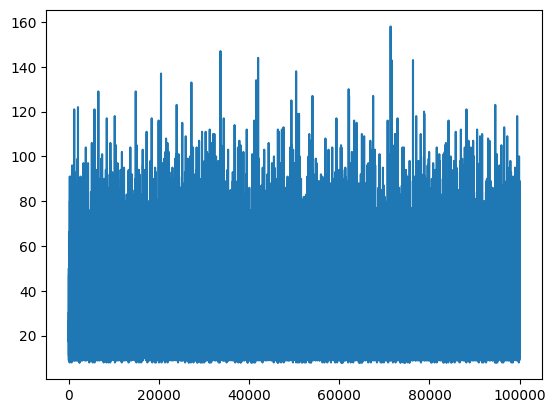

In [36]:
plt.plot(rewards)

From this graph, it is not possible to tell anything, because due to the nature of stochastic training process the length of training sessions varies greatly. To make more sense of this graph, we can calculate the running average over a series of experiments, let's say 100. This can be done conveniently using np.convolve:

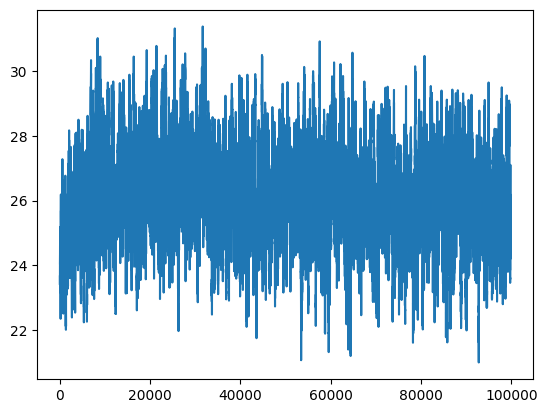

In [37]:
def running_average(X,window):
    return np.convolve(X,np.ones(window)/window,mode='valid')

plt.plot(running_average(rewards,100))

Varying hyperparameters
To make learning more stable, it makes sense to adjust some of our hyperparameters during training. In particular:


For learning rate, alpha, we may start with values close to 1, and then keep decreasing the parameter. With time, we will be getting good probability values in the Q-Table, and thus we should be adjusting them slightly, and not overwriting completely with new values.


Increase epsilon. We may want to increase the epsilon slowly, in order to explore less and exploit more. It probably makes sense to start with lower value of epsilon, and move up to almost 1.

Seeing the result in action


It would be interesting to actually see how the trained model behaves. Let's run the simulation and follow the same action selection strategy as during training, sampling according to the probability distribution in Q-Table: (code block 13)

In [48]:
import gymnasium as gym
# ... (rest of your imports and functions: discretize, qvalues, probs, etc.)

# --- STEP 1: RE-INITIALIZE THE ENVIRONMENT ---
# If your environment was created with a specific render_mode, use it here:
env = gym.make("CartPole-v1", render_mode="human") 
# ---------------------------------------------


# STEP 2: Run the Episode
obs, info = env.reset() # This now resets a FRESH environment
terminated = False
truncated = False

while not (terminated or truncated):
    s = discretize(obs)
    env.render()
    v = probs(np.array(qvalues(s)))
    a = random.choices(actions, weights=v)[0]
    
    # Correct (Using placeholders for reward, terminated, truncated, and info):
    obs, _, terminated, truncated, _ = env.step(a)

# STEP 3: Close the display surface when done
env.close()